# BatchNorm makes one example's output depend on its batchmates

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Measuring what a batchmate does

In [1]:
import numpy as np

rng = np.random.default_rng(0)
D, EPS = 16, 1e-5

def batch_norm(X):                       # statistics down each column
    mu, var = X.mean(axis=0), X.var(axis=0)
    return (X - mu) / np.sqrt(var + EPS)

def layer_norm(X):                       # statistics across each row
    mu, var = X.mean(axis=1, keepdims=True), X.var(axis=1, keepdims=True)
    return (X - mu) / np.sqrt(var + EPS)

x = rng.normal(1.0, 2.0, size=(1, D))    # the example we care about
batch_a = np.vstack([x, rng.normal(1.0, 2.0, size=(7, D))])
batch_b = np.vstack([x, rng.normal(3.0, 2.0, size=(7, D))])  # shifted companions

for name, norm in (("BatchNorm", batch_norm), ("LayerNorm", layer_norm)):
    diff = np.abs(norm(batch_a)[0] - norm(batch_b)[0]).max()
    print(f"{name}: max change in x's output = {diff:.3g}")
print("LayerNorm, x alone vs in batch:",
      np.abs(layer_norm(x)[0] - layer_norm(batch_a)[0]).max())
print("BatchNorm of x alone:", batch_norm(x)[0, :4])

BatchNorm: max change in x's output = 1.52
LayerNorm: max change in x's output = 0
LayerNorm, x alone vs in batch: 0.0
BatchNorm of x alone: [0. 0. 0. 0.]


## What eval mode fixes, and what it leaves

In [2]:
pop_mean, pop_std, trials = 1.0, 2.0, 100_000
rms = lambda a: np.sqrt(np.mean(a**2))
print("   B  Var(mu_B)/s^2   1/B  E[var_B]/s^2  eval/train rms  gap rms  sqrt(1.5/B)")
for B in (2, 8, 32, 128):
    batches = rng.normal(pop_mean, pop_std, size=(trials, B))
    mu_b, var_b = batches.mean(axis=1), batches.var(axis=1)
    y_train = (batches - mu_b[:, None]) / np.sqrt(var_b[:, None] + EPS)
    y_eval = (batches - pop_mean) / pop_std      # converged running statistics
    print(f"{B:4d} {mu_b.var() / pop_std**2:12.4f} {1/B:7.4f} {var_b.mean() / pop_std**2:11.3f}"
          f" {rms(y_eval) / rms(y_train):13.3f} {rms(y_train - y_eval):9.3f} {np.sqrt(1.5 / B):10.3f}")

   B  Var(mu_B)/s^2   1/B  E[var_B]/s^2  eval/train rms  gap rms  sqrt(1.5/B)
   2       0.4983  0.5000       0.504         1.003     0.931      0.866
   8       0.1247  0.1250       0.876         1.001     0.441      0.433


  32       0.0314  0.0312       0.968         1.000     0.218      0.217


 128       0.0077  0.0078       0.992         1.000     0.108      0.108


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

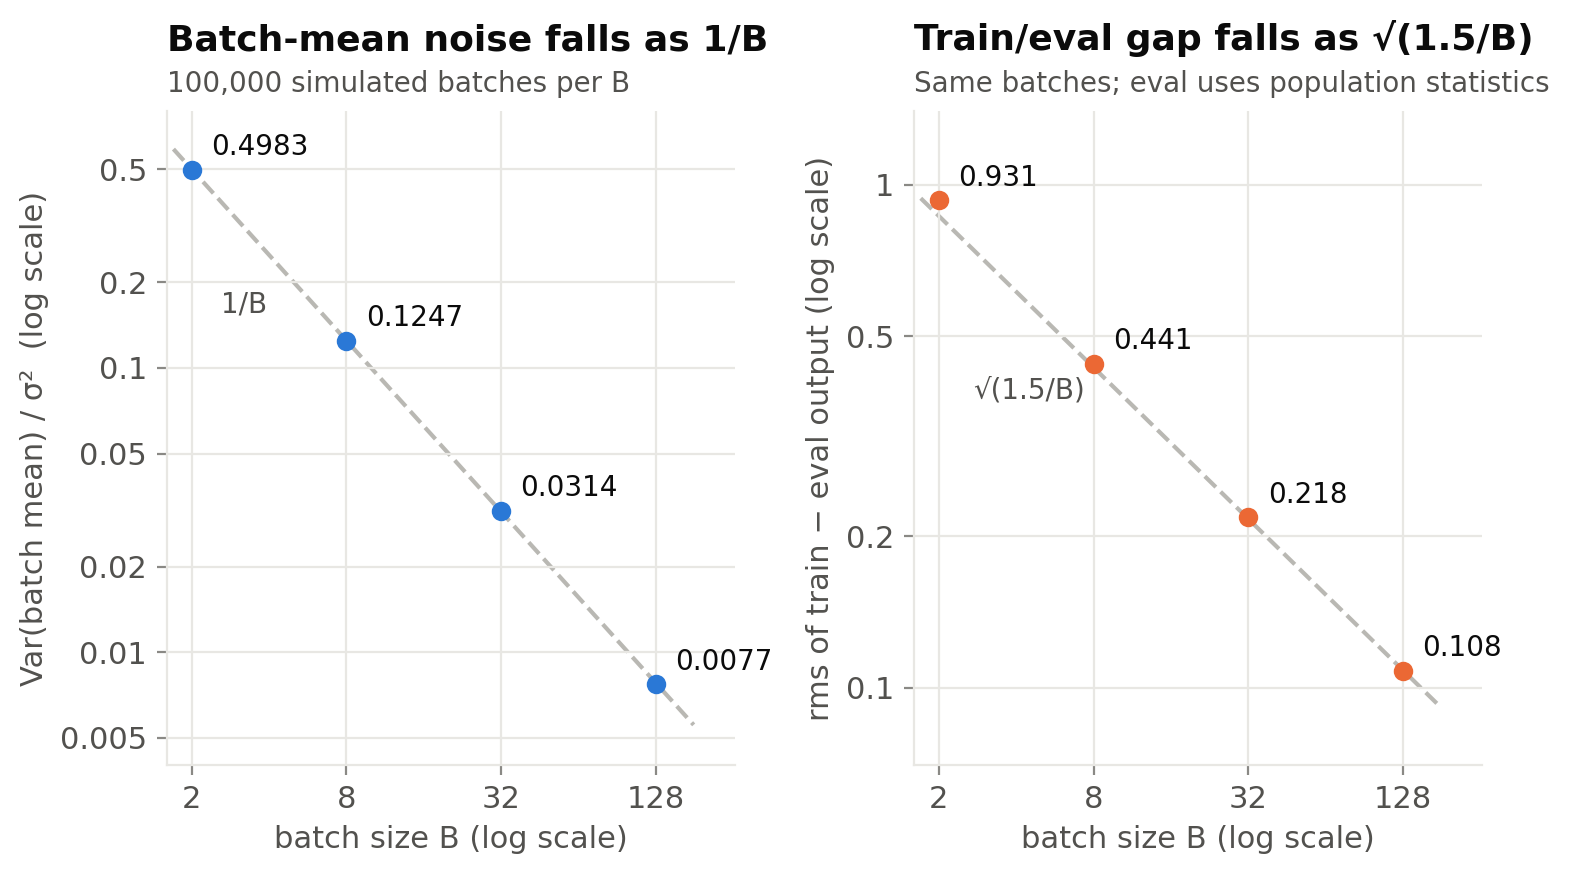

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # Reproduce the article's seeded draws in order, so the measured values
    # match its printed table (0.4983 ... 0.0077 and 0.931 ... 0.108).
    rng = np.random.default_rng(0)
    D, EPS = 16, 1e-5
    rng.normal(1.0, 2.0, size=(1, D))
    rng.normal(1.0, 2.0, size=(7, D))
    rng.normal(3.0, 2.0, size=(7, D))

    pop_mean, pop_std, trials = 1.0, 2.0, 100_000
    rms = lambda a: np.sqrt(np.mean(a**2))
    Bs, ratios, gaps = [2, 8, 32, 128], [], []
    for B in Bs:
        batches = rng.normal(pop_mean, pop_std, size=(trials, B))
        mu_b, var_b = batches.mean(axis=1), batches.var(axis=1)
        y_train = (batches - mu_b[:, None]) / np.sqrt(var_b[:, None] + EPS)
        y_eval = (batches - pop_mean) / pop_std
        ratios.append(mu_b.var() / pop_std**2)
        gaps.append(rms(y_train - y_eval))
        print(f"B={B:3d}  Var(mu_B)/sigma^2 = {ratios[-1]:.4f}  gap rms = {gaps[-1]:.3f}")

    f, (ax, bx) = fig(1, 2, sharex=True)
    bb = np.geomspace(1.7, 180, 60)

    ax.plot(bb, 1 / bb, color=NEUTRAL, lw=1.5, ls="--", zorder=1)
    ax.text(3.2, 1 / 3.2 * 0.6, "1/B", color=INK_2, fontsize=10, ha="center", va="top")
    ax.plot(Bs, ratios, "o", color=S1, ms=6, zorder=3)
    for B, r in zip(Bs, ratios):
        ax.annotate(f"{r:.4f}", (B, r), xytext=(7, 3), textcoords="offset points",
                    color=INK, fontsize=10, ha="left", va="bottom")
    ax.set_yscale("log")
    ax.set_yticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    ax.set_yticklabels(["0.005", "0.01", "0.02", "0.05", "0.1", "0.2", "0.5"])
    ax.set_ylim(0.004, 0.8)
    ax.set_ylabel("Var(batch mean) / σ²  (log scale)")
    ax.set_title("Batch-mean noise falls as 1/B")
    subtitle(ax, "100,000 simulated batches per B")

    bx.plot(bb, np.sqrt(1.5 / bb), color=NEUTRAL, lw=1.5, ls="--", zorder=1)
    bx.text(4.5, np.sqrt(1.5 / 4.5) * 0.72, "√(1.5/B)", color=INK_2, fontsize=10, ha="center", va="top")
    bx.plot(Bs, gaps, "o", color=S2, ms=6, zorder=3)
    for B, g in zip(Bs, gaps):
        bx.annotate(f"{g:.3f}", (B, g), xytext=(7, 3), textcoords="offset points",
                    color=INK, fontsize=10, ha="left", va="bottom")
    bx.set_yscale("log")
    bx.set_yticks([0.1, 0.2, 0.5, 1.0])
    bx.set_yticklabels(["0.1", "0.2", "0.5", "1"])
    bx.set_ylim(0.07, 1.4)
    bx.set_ylabel("rms of train − eval output (log scale)")
    bx.set_title("Train/eval gap falls as √(1.5/B)")
    subtitle(bx, "Same batches; eval uses population statistics")

    for a in (ax, bx):
        a.set_xscale("log", base=2)
        a.set_xticks([2, 8, 32, 128])
        a.set_xticklabels(["2", "8", "32", "128"])
        a.minorticks_off()
        a.set_xlim(1.6, 260)
        a.set_xlabel("batch size B (log scale)")
    save(f, pathlib.Path(__file__).parent / "13-batch-statistics-noise.png")
import matplotlib.pyplot as plt
plt.show()